In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
import matplotlib as mpl

/Users/shubdeepmohapatra/Desktop/CV-DV-Benchmarking-/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


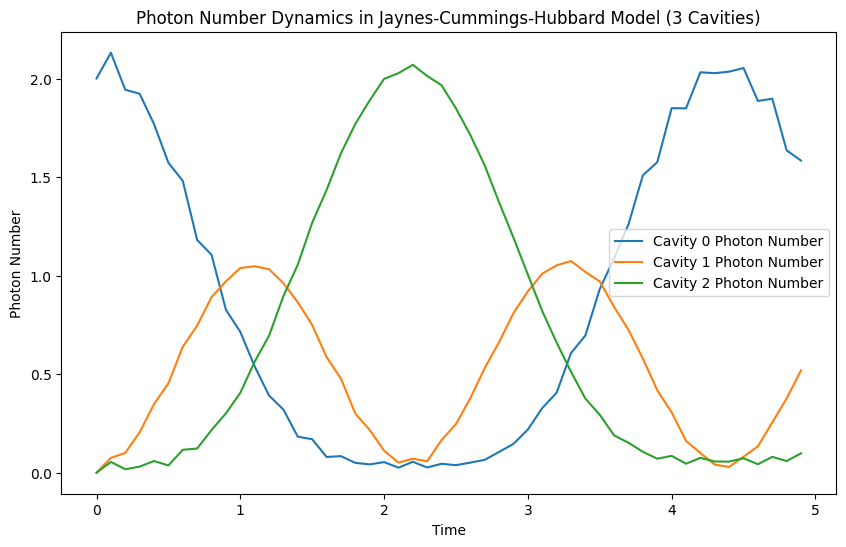

In [2]:
N_cavities = 3
N_levels = 64
g = 0.5 * 2 * np.pi     # Jaynes-Cummings coupling strength
J = 1.0                 # Photon hopping strength between cavities
omega_c = 2.0 * 2 * np.pi
omega_q = 3.0 * 2 * np.pi
timesteps = np.arange(0, 5, 0.1)


a_list = []
sm_list = []
sx_list = []
sy_list = []
sz_list = []

for i in range(N_cavities):
    ops = [qeye(N_levels) for _ in range(N_cavities)] + [qeye(2) for _ in range(N_cavities)]

    ops[i] = destroy(N_levels)
    a_list.append(tensor(ops))
    ops[i] = qeye(N_levels)

    ops[N_cavities + i] = sigmam()
    sm_list.append(tensor(ops))
    ops[N_cavities + i] = sigmax()
    sx_list.append(tensor(ops))
    ops[N_cavities + i] = sigmay()
    sy_list.append(tensor(ops))
    ops[N_cavities + i] = sigmaz()
    sz_list.append(tensor(ops))


H = 0

for i in range(N_cavities):
    H += omega_c * a_list[i].dag() * a_list[i]  # Photon Term
    H += omega_q * sz_list[i]  # Qubit Term
    H += g/2 * ((sx_list[i] * (a_list[i].dag() + a_list[i])) -            
                  1j * (sy_list[i] * (a_list[i].dag() - a_list[i])))   # Interaction term

# Hopping terms between adjacent cavities
for i in range(N_cavities - 1):
    H += -J * (a_list[i].dag() * a_list[i + 1] + a_list[i] * a_list[i + 1].dag())

# Initial state: photon in the first cavity, all qubits in ground state
initial_state = tensor(
    [basis(N_levels, 2) if i == 0 else basis(N_levels, 0) for i in range(N_cavities)] +
    [basis(2, 0) for _ in range(N_cavities)]
)

observables = [a.dag() * a for a in a_list] + sx_list
result = mesolve(H, initial_state, timesteps, [], observables)

photon_numbers = np.array(result.expect[:N_cavities])
qubit_states = np.array(result.expect[N_cavities:])

# Plot the photon number dynamics
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for i in range(N_cavities):
    plt.plot(timesteps, photon_numbers[i], label=f"Cavity {i} Photon Number")

plt.xlabel("Time")
plt.ylabel("Photon Number")
plt.legend()
plt.title(f"Photon Number Dynamics in Jaynes-Cummings-Hubbard Model ({N_cavities} Cavities)")
plt.show()

